In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
df = pd.read_csv('housing.csv')

In [54]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [55]:
df = df.dropna()

In [56]:
df = pd.get_dummies(df, drop_first=True)

In [57]:
X =df.drop("median_house_value", axis=1).to_numpy()
y = df["median_house_value"].to_numpy()

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [59]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [61]:
model = SGDRegressor(
    max_iter=10000,
    learning_rate= 'constant',
    eta0= 0.000001,
    warm_start= True,
    random_state= 42
)

In [62]:
model.fit(X_train_scaled,y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,10000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [63]:
y_predict = model.predict(X_test_scaled)

In [64]:
mse = mean_squared_error(y_test, y_predict)

In [65]:
r2 = r2_score(y_test, y_predict)

In [66]:
print("Weights (w):")
print(model.coef_)

print("\nBias (b):")
print(model.intercept_)

print("\nMSE:")
print(mse)

print("\nR2 Score:")
print(r2)

Weights (w):
[ 0.00000000e+00 -2.78273392e+04 -1.82413210e+04 -3.65516384e+03
 -1.30978911e+04  1.20275066e+04 -1.26413516e+04 -2.62241900e+03
  2.66754720e+04 -3.07017586e+03  1.20915801e+03 -3.18641384e+03
 -5.99709118e+03  2.50498625e+04  1.23513355e+04  4.19935199e+03
  1.15769938e+04 -1.30108535e+04  1.00651686e+04  1.59481882e+03
 -2.77099833e+04  2.37609593e+03 -1.20877579e+03  2.40555926e+03
  2.08559433e+03 -2.35098427e+04 -1.71361813e+04 -1.04440254e+04
  1.21525704e+04 -6.56722332e+03 -3.02815323e+03  2.02023803e+04
  3.20330143e+03  1.21057840e+03 -5.30961920e+03  2.57425309e+03
  1.63386620e+04 -1.76225829e+04  3.54727853e+04 -2.44720118e+04
  2.22230836e+04  1.97654895e+04 -6.01909641e+03 -1.45043145e+03
  7.03852530e+03  3.91066562e+03  9.05169026e+03 -7.96760073e+02
 -2.92507237e+03  1.76975296e+03  2.48532172e+04  5.66980004e+02
 -5.21434381e+02  1.27617465e+03 -2.15118846e+03 -1.36490997e+04
  4.91430195e+03 -7.06679624e+03  1.93127093e+04 -1.03848322e+04
  6.10503412

In [68]:
print("\nFirst 5 Predictions:\n")

for actual, pred in zip(y_test[:5], y_predict[:5]):
    print(
        f"Actual: {actual:.2f} | "
        f"Predicted: {pred:.2f}"
    )


First 5 Predictions:

Actual: 245800.00 | Predicted: 202749.86
Actual: 137900.00 | Predicted: 173598.03
Actual: 218200.00 | Predicted: 211038.24
Actual: 220800.00 | Predicted: 164389.01
Actual: 170500.00 | Predicted: 204930.37


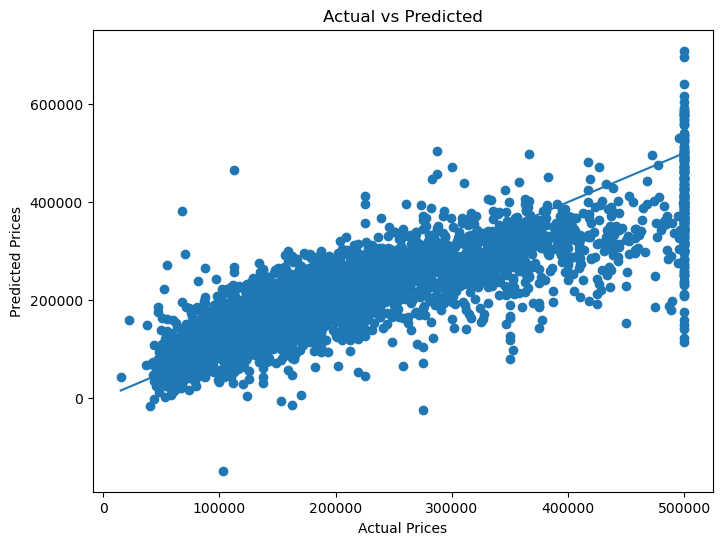

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_predict)

# ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

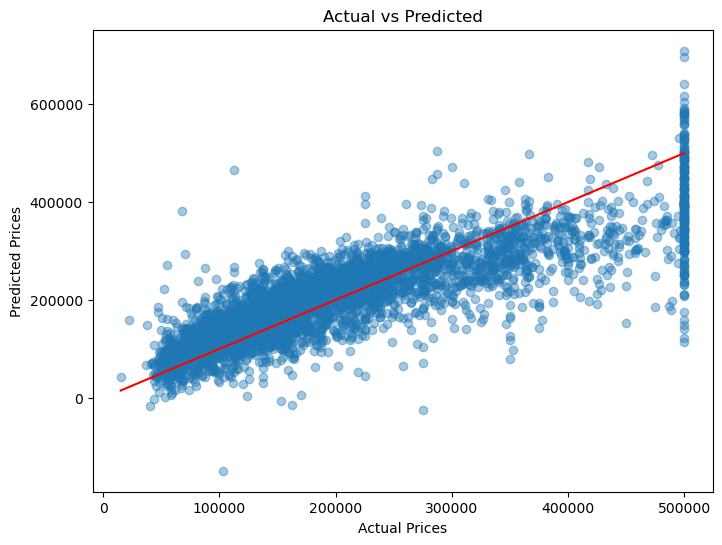

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_predict,
    alpha=0.4
)

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()